In [9]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
print(titanic.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [3]:
print("Mean Age:", titanic["age"].mean())
print("Median Age:", titanic["age"].median())
print("Mode Age:", titanic["age"].mode()[0])


Mean Age: 29.69911764705882
Median Age: 28.0
Mode Age: 24.0


In [4]:
print("Variance of Fare:", titanic["fare"].var())
print("Std Dev of Fare:", titanic["fare"].std())

Variance of Fare: 2469.436845743116
Std Dev of Fare: 49.6934285971809


In [6]:
print(titanic[["age", "fare", "survived"]].corr())

               age      fare  survived
age       1.000000  0.096067 -0.077221
fare      0.096067  1.000000  0.257307
survived -0.077221  0.257307  1.000000


array([[<Axes: title={'center': 'survived'}>,
        <Axes: title={'center': 'pclass'}>],
       [<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'sibsp'}>],
       [<Axes: title={'center': 'parch'}>,
        <Axes: title={'center': 'fare'}>]], dtype=object)

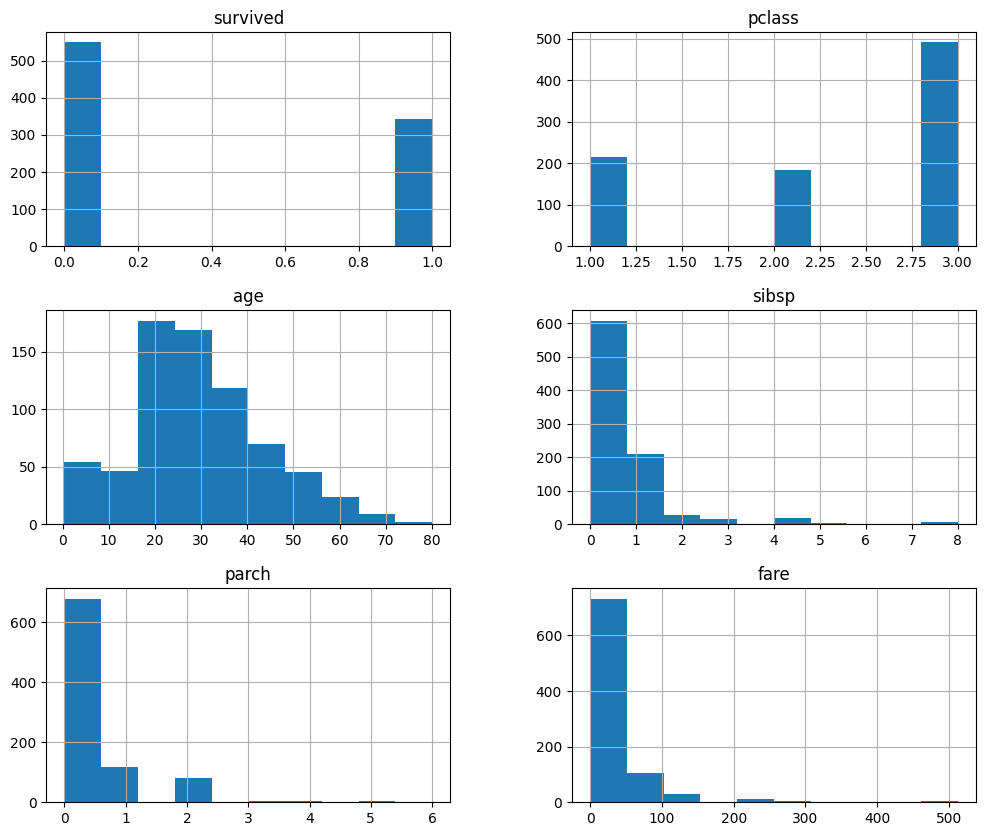

In [7]:
titanic.hist(figsize=(12, 10))

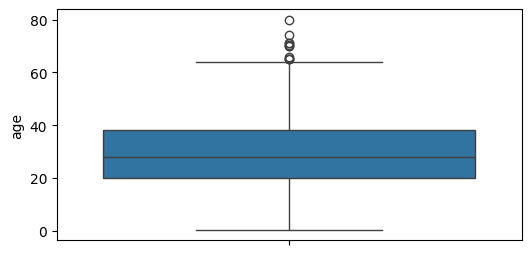

In [20]:
plt.figure(figsize=(6, 3))
sns.boxplot(data=titanic, y='age')
plt.show()

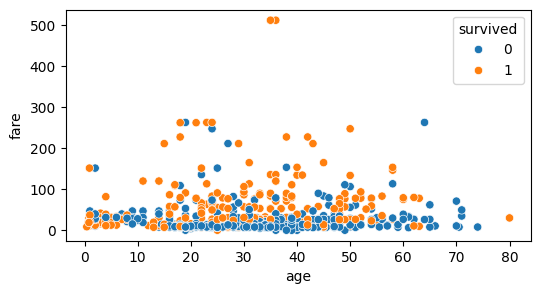

In [19]:
plt.figure(figsize=(6, 3))
sns.scatterplot(data=titanic, x='age', y='fare', hue='survived')
plt.show()

In [14]:
import numpy as np

# Simulate survival probability based on passenger class
survival_by_class = titanic.groupby('pclass')['survived'].mean()
print("Survival probability by class:")
print(survival_by_class)

# Simulate 1000 passengers and predict survival
np.random.seed(42)
n_simulations = 1000
simulated_survival = []

for _ in range(n_simulations):
    # Randomly select a class (1, 2, or 3)
    pclass = np.random.choice([1, 2, 3], p=[0.24, 0.21, 0.55])
    # Get survival probability for that class
    prob = survival_by_class[pclass]
    # Simulate survival (1 or 0)
    survived = np.random.binomial(1, prob)
    simulated_survival.append(survived)

print(f"\nSimulated survival rate: {np.mean(simulated_survival):.2%}")
print(f"Actual survival rate: {titanic['survived'].mean():.2%}")

Survival probability by class:
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

Simulated survival rate: 38.40%
Actual survival rate: 38.38%


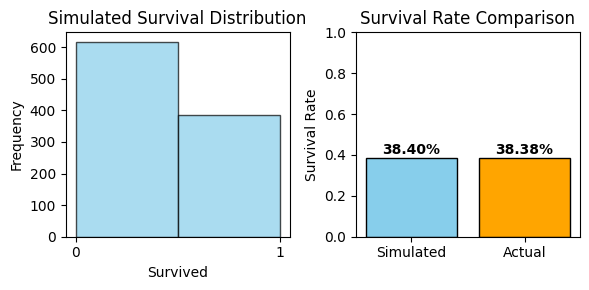

In [18]:
plt.figure(figsize=(6, 3))

# Plot histogram of simulated survival
plt.subplot(1, 2, 1)
plt.hist(simulated_survival, bins=2, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Survived')
plt.ylabel('Frequency')
plt.title('Simulated Survival Distribution')
plt.xticks([0, 1])

# Plot comparison bar chart
plt.subplot(1, 2, 2)
categories = ['Simulated', 'Actual']
rates = [np.mean(simulated_survival), titanic['survived'].mean()]
plt.bar(categories, rates, color=['skyblue', 'orange'], edgecolor='black')
plt.ylabel('Survival Rate')
plt.title('Survival Rate Comparison')
plt.ylim([0, 1])

for i, v in enumerate(rates):
    plt.text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()